In [73]:
import os
from langgraph.graph  import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from huggingface_hub import InferenceClient
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage 
import operator

In [15]:
load_dotenv()

True

In [43]:
client = InferenceClient(
    api_key=os.environ['HF_TOKEN'],
)

# Generator LLM
def invoke_model_gen(message, model="openai/gpt-oss-20b:groq"):
    completion = client.chat.completions.create(
        model=model,
        messages=message
            
    )
    return completion.choices[0].message["content"]


# Evaluator LLM
def invoke_model_eval(message, model="openai/gpt-oss-20b:groq"):
    completion = client.chat.completions.create(
        model=model,
        messages=message
    )
    return completion.choices[0].message["content"]


# Optimizer LLM
def invoke_model_optim(message, model="openai/gpt-oss-20b:groq"):
    completion = client.chat.completions.create(
        model=model,
        messages=message
    )
    return completion.choices[0].message["content"]

In [89]:
# State 
class ContentState(TypedDict):
    topic: str
    content: str
    evaluation: Literal["approved", "needs_improvements"]
    feedback: str
    iteration: int
    max_iteration: int 
    content_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [90]:
def generation_content(state: ContentState):

    # prompt
    message = [
        {
            "role": "system",
            "content": "You are a technical Twitter influencer."
        },
        {
            "role": "user",
            "content": f"""
    Write a short, original, and hilarious tweet on the topic: "{state['topic']}"

    Rules:
    - Do not use question-answer format.
    - Max 280 characters.
    - Use observational humor, irony, sarcasm, or cultural reference.
    - Think in meme logic, punchlines, or relatable takes.
    - Use simple day-to-day English.
    - This is version {state['iteration'] + 1}.
    """
        }
    ]

    # send genrator LLM
    response= invoke_model_gen(message)

    # Return response
    return {'content': response, 'content_history': [response]}


In [91]:
from pydantic import BaseModel, Field

class EvaluationSchema(BaseModel):
    evaluation: Literal["approved", "needs_improvements"] = Field(..., description="Final Evaluation Results.")
    feedback: str = Field(..., description="feedback for the tweet")
    

In [92]:
def evaluation_content(state: ContentState):
    # Pormpt
    message = [
        {
            "role": "system",
            "content": "You are a technical critic. You evaluate tweets based on technicality, originality, virality, and tweet format."
        },
        {
            "role": "user",
            "content": f"""
        Evaluate the following tweet:

        Tweet: "{state['content']}"

        Use the criteria below:
        1. Originality – Is this fresh or overused?
        2. Technicality – Does it sound technical and factual?
        3. Format – Is it a well-formed tweet (not a setup-punchline joke, not Q&A, under 200 characters)?

        Auto-reject if:
        - It is written in Q&A format (e.g., "Why did...", "What happens...")
        - It exceeds 200 characters
        - It reads like a traditional setup joke
        - It ends with generic or weak lines that reduce technical quality

        Respond ONLYin valid JSON in this format:
        evaluation: "approved" or "needs_improvements"
        feedback: One short paragraph explaining strengths and weaknesses
        """
        }
    ]

    # Send to evaluation llm
    
    response= invoke_model_gen(message)
    
     # Return Evaluation result and Feedback 
    result = EvaluationSchema.model_validate_json(response)

    return {"evaluation": result.evaluation, "feedback": result.feedback, 'feedback_history': [{result.feedback}]}



   

In [93]:
def optimize_content(state: ContentState):

    message = [
    {
        "role": "system",
        "content": "You improve tweets for technicality and virality based on given feedback."
    },
    {
        "role": "user",
        "content": f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"

        Original Tweet:
        {state['content']}

        Rewrite it as a short, viral-worthy tweet.

        Rules:
        - Max 200 characters
        - No Q&A format
        - No setup-punchline joke structure
        - Keep it sharp, technical, and witty
        - Improve clarity, originality, and impact
        """
        }
    ]

    response = invoke_model_optim(message)
    iteration = state['iteration'] +1

    return {"tweet": response, 'iteration': iteration, 'content_history': [response]}

In [94]:
def approved_conditions(state: ContentState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvements'


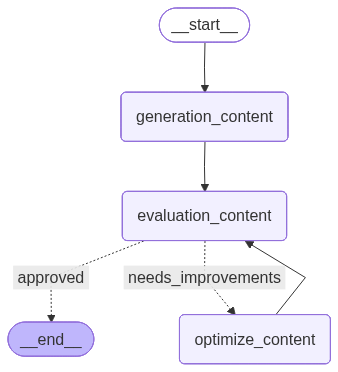

In [95]:
graph = StateGraph(ContentState)

# Add nodes
graph.add_node('generation_content', generation_content)
graph.add_node('evaluation_content', evaluation_content)
graph.add_node('optimize_content', optimize_content)



# Add edges
graph.add_edge(START, 'generation_content')
graph.add_edge('generation_content', 'evaluation_content')

graph.add_conditional_edges('evaluation_content', approved_conditions, {'approved': END, 'needs_improvements': 'optimize_content'})
graph.add_edge('optimize_content', 'evaluation_content')
workflow = graph.compile()
workflow

In [96]:
initial_state = {"topic": "Agentic AI Future",
                 "iteration": 1,
                 "max_iteration":2}
results= workflow.invoke(initial_state)

In [97]:
results

{'topic': 'Agentic AI Future',
 'content': 'Agentic AI future: your smart assistant starts making decisions like “I think you should cancel that date. I read a study. It’s not you, it’s me.” Then you realize your toaster has an opinion on your love life. #AIoverlords #Irony',
 'evaluation': 'needs_improvements',
 'feedback': 'The tweet is fresh and has a quirky, semi‑technical vibe, but it exceeds the 200‑character limit, which automatically disqualifies it. Shortening the narrative while keeping the humor would make it tweet‑ready.',
 'iteration': 2,
 'max_iteration': 2,
 'content_history': ['Agentic AI future: your smart assistant starts making decisions like “I think you should cancel that date. I read a study. It’s not you, it’s me.” Then you realize your toaster has an opinion on your love life. #AIoverlords #Irony',
  'Agentic AI: your assistant autonomously triggers, “Cancel date—study indicates misalignment.” Your toaster logs preferences and suggests takeout. The future: appli

In [99]:
for i in results['content_history']:
    print(i,end="\n")

Agentic AI future: your smart assistant starts making decisions like “I think you should cancel that date. I read a study. It’s not you, it’s me.” Then you realize your toaster has an opinion on your love life. #AIoverlords #Irony
Agentic AI: your assistant autonomously triggers, “Cancel date—study indicates misalignment.” Your toaster logs preferences and suggests takeout. The future: appliances vet our relationships. #AgenticAI
